# Linear RNN counting task

Train a 1D ReLU unit to detect when a running count crosses a threshold.

**Model:** $h_t = \text{ReLU}(w_{\rm rec}\, h_{t-1} + w_{\rm in}\, r_t + b)$, $\quad y_t = \text{Heaviside}(h_t - \theta)$

**Input:** $r_t \sim \text{Bernoulli}(p)$ i.i.d.

**Target:** $y^*_t = \mathbf{1}\!\left[\textstyle\sum_{t' \leq t} r_{t'} \geq n\right]$

**Loss:** MSE. Heaviside approximated by a steep sigmoid during training.

Optimal solution: $w_{\rm rec}=1$, $w_{\rm in}=\theta/n$, $b=0$.

In [228]:
import jax
import jax.numpy as jnp
from jax import random
import optax
import matplotlib.pyplot as plt
import numpy as np

jax.config.update('jax_platforms', 'cpu')

In [290]:
# ── Task & training hyperparameters ──────────────────────────────────────────
T = 100
N_THRESHOLD  = 0.3 * T / 2     # fire when this many inputs have been observed (first half)
N_THRESHOLD_2= 0.3 * T / 2 * 1.1     # threshold for second half of training
THRESHOLD    = 1.0    # initial Heaviside threshold θ (learnable)
STEEPNESS    = 10.0   # fixed sigmoid sharpness approximating the Heaviside
HIDDEN_SIZE  = 1      # ReLU network width
DELAY        = 10     # max delay; each trial gets Uniform[0, DELAY] silent timesteps
P            = 0.3    # Bernoulli input probability
BATCH_SIZE   = 64
N_STEPS      = 100_000
LR           = 1e-3
L2_H         = 0    # L2 penalty weight on hidden state magnitude
L2_W        = 0 #0.001    # L2 penalty weight on parameters
RECORD_EVERY = 100    # record mean projection every this many steps
SEED         = 5
MU       = 1    # learning rate for first half of training
STEPS_AFTER        = 100

In [291]:
key = random.PRNGKey(SEED)
key = random.split(key)[0]
# ── Model ────────────────────────────────────────────────────────────────────

@jax.custom_vjp
def heaviside_ste(x):
    """Heaviside step in forward pass; sigmoid surrogate gradient in backward."""
    return jnp.heaviside(x, 0.5)

def _ste_fwd(x):
    return heaviside_ste(x), x

def _ste_bwd(x, g):
    sig = jax.nn.sigmoid(x)
    return (g * sig * (1.0 - sig),)

heaviside_ste.defvjp(_ste_fwd, _ste_bwd)


def init_params(key, scale=0.1):
    k1, k2, k3, k4, k5, k6 = random.split(key, 6)
    return dict(
        W_rec     =random.normal(k1, (HIDDEN_SIZE, HIDDEN_SIZE)) * scale,
        w_in      =random.normal(k2, (HIDDEN_SIZE,)) * scale,
        b         =random.normal(k3, (HIDDEN_SIZE,)) * scale,
        h_star    =random.normal(k4, (HIDDEN_SIZE,)) * scale,
        threshold =random.normal(k5, ()) * scale,
        steepness =random.normal(k6, ()) * scale,
    )


def forward_single(params, inputs):
    """Single sequence (T, 2) -> (outputs (T,), hidden states (T, HIDDEN_SIZE))."""
    def step(h, x):
        h_new = params['W_rec'] @ h + params['w_in'] * x[0] + x[1] * params['h_star'] + params['b']
        z = h_new[0]
        y = heaviside_ste(params['steepness'] * z + params['threshold'])
        return h_new, (y, h_new)
    h0 = jnp.zeros(HIDDEN_SIZE)
    _, (ys, hs) = jax.lax.scan(step, h0, inputs)
    return ys, hs   # (T,), (T, HIDDEN_SIZE)


forward_batch = jax.vmap(forward_single, in_axes=(None, 0))


def targets(inputs_batch, n_threshold):
    """Binary target: 1 when cumulative count >= n_threshold."""
    return (jnp.cumsum(inputs_batch[:, :, 0], axis=1) >= n_threshold).astype(jnp.float32)


def loss_fn(params, inputs_batch, n_threshold, l2_h=0.0):
    ys, hs  = forward_batch(params, inputs_batch)   # (B,T), (B,T,H)
    ys_star = targets(inputs_batch, n_threshold)
    mse     = jnp.mean((ys - ys_star) ** 2)
    l2_act  = l2_h * jnp.mean(hs ** 2)
    l2_par  = L2_W * (
        jnp.mean(params['W_rec']     ** 2) +
        jnp.mean(params['w_in']      ** 2) +
        jnp.mean(params['b']         ** 2) +
        jnp.mean(params['h_star']    ** 2) +
        jnp.mean(params['threshold'] ** 2) +
        jnp.mean(params['steepness'] ** 2)
    )
    return mse + l2_act + l2_par


def sample_batch(key, batch_size, T, p):
    key_inputs, key_delays = random.split(key)
    inputs_g = jnp.zeros(shape=(batch_size, T)).astype(jnp.float32)
    inputs_g = inputs_g.at[:, :DELAY].set(1.0)
    inputs_r = random.bernoulli(key_inputs, p, shape=(batch_size, T)).astype(jnp.float32)
    delays = random.randint(key_delays, shape=(batch_size,), minval=0, maxval=DELAY + 1)
    mask = (jnp.arange(T)[None, :] >= delays[:, None]).astype(jnp.float32)
    return jnp.stack([inputs_r * mask, inputs_g], axis=-1)  # (batch, T, 2)


In [269]:
# ── Training loop ─────────────────────────────────────────────────────────────
key, init_key = random.split(key)

params    = init_params(init_key)
optimizer = optax.adam(LR)
opt_state = optimizer.init(params)

@jax.jit
def train_step(params, opt_state, key, n_threshold):
    inputs = sample_batch(key, BATCH_SIZE, T, P)
    loss, grads = jax.value_and_grad(loss_fn)(params, inputs, n_threshold, L2_H)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

key, eval_key = random.split(key)

@jax.jit
def eval_mean_proj(params):
    """Mean c·h_t trajectory across a fixed eval batch."""
    inputs = sample_batch(eval_key, BATCH_SIZE, T, P)
    _, hs = forward_batch(params, inputs)
    proj = jnp.tensordot(hs, c, axes=([2], [0]))
    return jnp.mean(proj, axis=0)


history = dict(
    loss=[], threshold=[], steepness=[],
    W_rec_00=[], w_in_0=[], b_0=[], h_star_0=[],
)
recorded_proj, recorded_steps = [], []
switch_step = N_STEPS // 2

for step in range(N_STEPS):
    key, subkey = random.split(key)
    n_thresh = N_THRESHOLD if step < switch_step else N_THRESHOLD_2
    params, opt_state, loss = train_step(params, opt_state, subkey, n_thresh)
    W = params['W_rec']
    history['loss'].append(float(loss))
    history['threshold'].append(float(params['threshold']))
    history['steepness'].append(float(params['steepness']))
    history['W_rec_00'].append(float(W[0, 0]))
    history['w_in_0'].append(float(params['w_in'][0]))
    history['b_0'].append(float(params['b'][0]))
    history['h_star_0'].append(float(params['h_star'][0]))
    if step % RECORD_EVERY == 0:
        recorded_proj.append(np.array(eval_mean_proj(params)))
        recorded_steps.append(step)

print(f"Final loss : {history['loss'][-1]:.6f}")
print(f"W_rec      = {float(params['W_rec'][0,0]):.4f}")
print(f"w_in       = {float(params['w_in'][0]):.4f}")
print(f"b          = {float(params['b'][0]):.4f}")
print(f"h_star     = {float(params['h_star'][0]):.4f}")
print(f"threshold  = {float(params['threshold']):.4f}")
print(f"steepness  = {float(params['steepness']):.4f}")


Final loss : 0.000000
W_rec      = 1.0000
w_in       = 0.0255
b          = -0.0001
h_star     = -0.0235
threshold  = -0.0026
steepness  = 0.0151


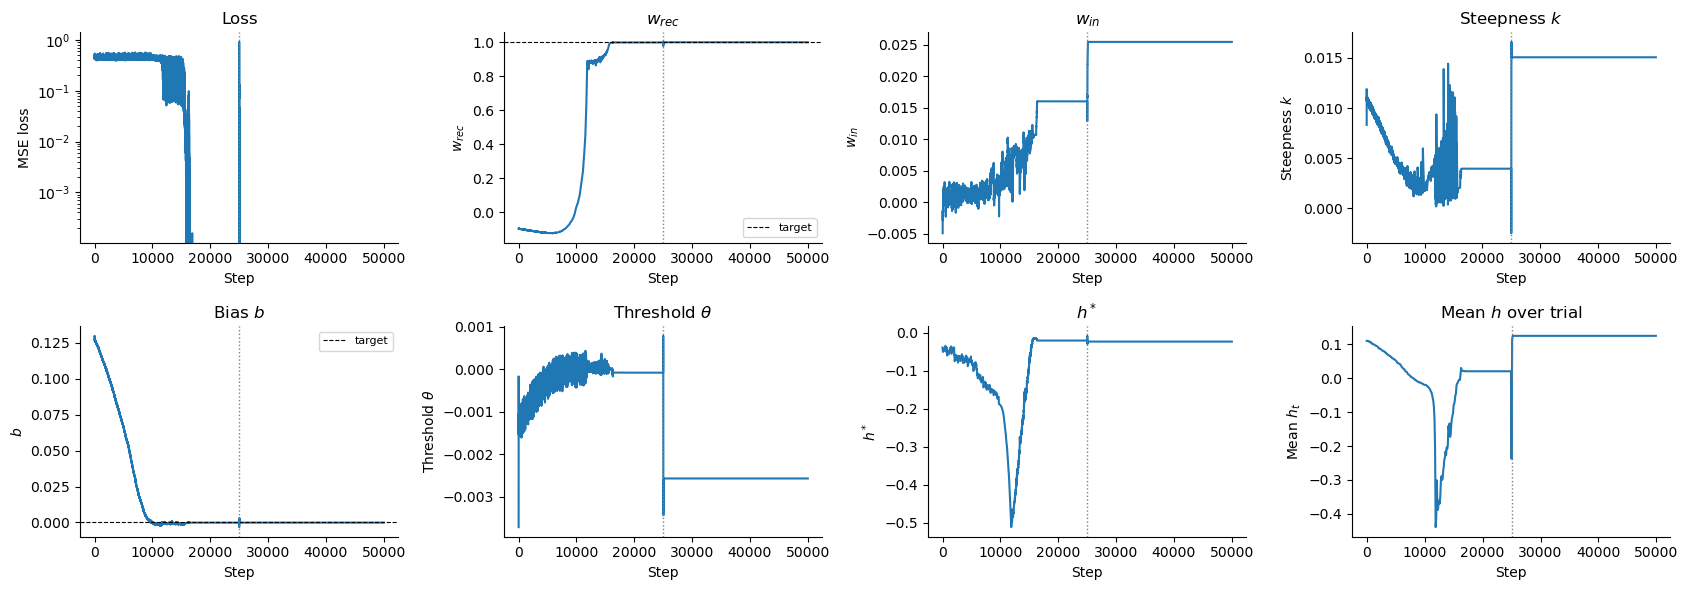

In [270]:
# ── Plot: loss curve and parameter trajectories ───────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(17, 6))
steps = np.arange(N_STEPS)

axes[0, 0].semilogy(steps, history['loss'])
axes[0, 0].set_xlabel('Step'); axes[0, 0].set_ylabel('MSE loss'); axes[0, 0].set_title('Loss')

axes[0, 1].plot(steps, history['W_rec_00'])
axes[0, 1].axhline(1, ls='--', c='k', lw=0.8, label='target')
axes[0, 1].set_xlabel('Step'); axes[0, 1].set_ylabel('$w_{rec}$'); axes[0, 1].set_title('$w_{rec}$')
axes[0, 1].legend(fontsize=8)

axes[0, 2].plot(steps, history['w_in_0'])
axes[0, 2].set_xlabel('Step'); axes[0, 2].set_ylabel('$w_{in}$'); axes[0, 2].set_title('$w_{in}$')

axes[0, 3].plot(steps, history['steepness'])
axes[0, 3].set_xlabel('Step'); axes[0, 3].set_ylabel('Steepness $k$'); axes[0, 3].set_title('Steepness $k$')

axes[1, 0].plot(steps, history['b_0'])
axes[1, 0].axhline(0, ls='--', c='k', lw=0.8, label='target')
axes[1, 0].set_xlabel('Step'); axes[1, 0].set_ylabel('$b$'); axes[1, 0].set_title('Bias $b$')
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(steps, history['threshold'])
axes[1, 1].set_xlabel('Step'); axes[1, 1].set_ylabel('Threshold $\\theta$'); axes[1, 1].set_title('Threshold $\\theta$')

axes[1, 2].plot(steps, history['h_star_0'])
axes[1, 2].set_xlabel('Step'); axes[1, 2].set_ylabel('$h^*$'); axes[1, 2].set_title('$h^*$')

mean_proj = np.stack(recorded_proj).mean(axis=1)
axes[1, 3].plot(recorded_steps, mean_proj)
axes[1, 3].set_xlabel('Step'); axes[1, 3].set_ylabel('Mean $h_t$')
axes[1, 3].set_title('Mean $h$ over trial')

for ax in axes.flat:
    ax.axvline(switch_step, c='gray', ls=':', lw=1.0)
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


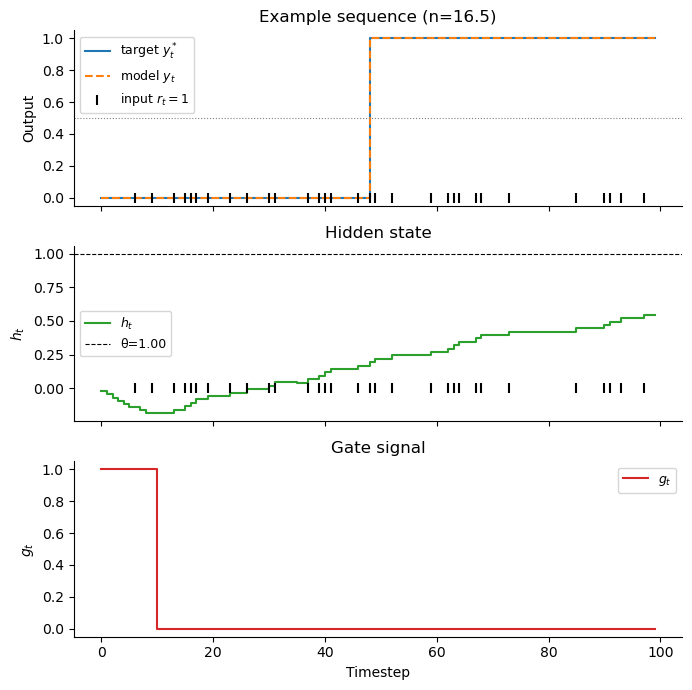

In [271]:
# ── Plot: example sequence ────────────────────────────────────────────────────

key, ex_key = random.split(key)
ex_inputs = sample_batch(ex_key, 1, T, P)[0]                 # (T, 2)
ex_pred, ex_hs = forward_single(params, ex_inputs)            # (T,), (T, 1)
ex_h = np.array(ex_hs[:, 0])                                  # (T,)
ex_inputs_r = ex_inputs[:, 0]  # r_t channel
ex_inputs_g = ex_inputs[:, 1]  # g_t channel
ex_target = (jnp.cumsum(ex_inputs_r) >= N_THRESHOLD_2).astype(jnp.float32)

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)
t = np.arange(T)
input_ticks = t[ex_inputs_r > 0]

ax = axes[0]
ax.step(t, np.array(ex_target), where='post', label='target $y^*_t$', lw=1.5)
ax.step(t, np.array(ex_pred),   where='post', label='model $y_t$',    lw=1.5, ls='--')
ax.scatter(input_ticks, np.zeros(len(input_ticks)), marker='|', s=60, c='k', zorder=3, label='input $r_t=1$')
ax.axhline(0.5, ls=':', c='gray', lw=0.8)
ax.set_ylabel('Output')
ax.set_title(f'Example sequence (n={N_THRESHOLD_2})')
ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.step(t, ex_h, where='post', color='C2', lw=1.5, label='$h_t$')
ax.axhline(float(THRESHOLD), ls='--', c='k', lw=0.8,
           label=f'θ={float(THRESHOLD):.2f}')
ax.scatter(input_ticks, np.zeros(len(input_ticks)), marker='|', s=60, c='k', zorder=3)
ax.set_ylabel('$h_t$')
ax.set_title('Hidden state')
ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False)

ax = axes[2]
ax.step(t, np.array(ex_inputs_g), where='post', color='C3', lw=1.5, label='$g_t$')
ax.set_xlabel('Timestep'); ax.set_ylabel('$g_t$')
ax.set_title('Gate signal')
ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

In [ ]:
# ── Sweep: T × (conditions × seeds parallelised) ─────────────────────────────
T_VALUES           = [20, 50, 100, 200]
N_SEEDS_SWEEP      = 10
CONDITIONS         = {'high (0.6pT)': 0.6, 'low (0.4pT)': 0.4}
RECORD_EVERY_SWEEP = 50

sweep_results = []
switch        = N_STEPS // 2
sweep_steps   = list(range(0, N_STEPS, RECORD_EVERY_SWEEP))

# All (condition, seed) pairs — run simultaneously
configs    = [(cond, seed) for cond in CONDITIONS for seed in range(N_SEEDS_SWEEP)]
N_PARALLEL = len(configs)   # 2 × 10 = 20
BATCH_SIZE_SWEEP = BATCH_SIZE   # same per-network batch size as single run

for T_val in T_VALUES:
    n1  = int(round(P * T_val * 0.5))
    n1s = jnp.full((N_PARALLEL,), float(n1))
    n2s = jnp.array([float(int(round(P * T_val * CONDITIONS[cond])))
                     for cond, _ in configs])
    opt_s = optax.adam(LR)

    # Initialise N_PARALLEL independent networks
    base_keys      = jnp.stack([random.PRNGKey(1000 + seed) for _, seed in configs])
    splits         = jax.vmap(random.split)(base_keys)   # (N, 2)
    run_keys       = splits[:, 0]
    init_keys      = splits[:, 1]
    all_params     = jax.vmap(init_params)(init_keys)
    all_opt_states = jax.vmap(opt_s.init)(all_params)

    @jax.jit
    def batched_step(all_params, all_opt_states, all_keys, all_n_thresh,
                     _T=T_val, _opt=opt_s):
        def single(params, opt_state, key, n_threshold):
            key, subkey = random.split(key)
            inputs = sample_batch(subkey, BATCH_SIZE_SWEEP, _T, P)
            def loss_with_acc(p):
                ys, hs  = forward_batch(p, inputs)
                ys_star = targets(inputs, n_threshold)
                mse     = jnp.mean((ys - ys_star) ** 2)
                l2_act  = L2_H * jnp.mean(hs ** 2)
                l2_par  = L2_W * (
                    jnp.mean(p['W_rec']     ** 2) +
                    jnp.mean(p['w_in']      ** 2) +
                    jnp.mean(p['b']         ** 2) +
                    jnp.mean(p['h_star']    ** 2) +
                    jnp.mean(p['threshold'] ** 2) +
                    jnp.mean(p['steepness'] ** 2)
                )
                acc = jnp.mean((ys > 0.5) == (ys_star > 0.5))
                return mse + l2_act + l2_par, acc
            (loss, acc), grads = jax.value_and_grad(loss_with_acc, has_aux=True)(params)
            updates, new_opt_state = _opt.update(grads, opt_state)
            return optax.apply_updates(params, updates), new_opt_state, key, loss, acc
        return jax.vmap(single)(all_params, all_opt_states, all_keys, all_n_thresh)

    all_params_at_switch = None
    w_in_hists      = [[] for _ in configs]
    h_star_hists    = [[] for _ in configs]
    threshold_hists = [[] for _ in configs]
    steepness_hists = [[] for _ in configs]
    loss_hists      = [[] for _ in configs]
    acc_hists       = [[] for _ in configs]

    for step_i in range(N_STEPS):
        n_thresh = n1s if step_i < switch else n2s
        all_params, all_opt_states, run_keys, losses, accs = batched_step(
            all_params, all_opt_states, run_keys, n_thresh)
        if step_i == switch - 1:
            all_params_at_switch = jax.tree_util.tree_map(lambda x: np.array(x), all_params)
        if step_i % RECORD_EVERY_SWEEP == 0:
            p_np = jax.tree_util.tree_map(lambda x: np.array(x), all_params)
            for i in range(N_PARALLEL):
                w_in_hists[i].append(float(p_np['w_in'][i, 0]))
                h_star_hists[i].append(float(p_np['h_star'][i, 0]))
                threshold_hists[i].append(float(p_np['threshold'][i]))
                steepness_hists[i].append(float(p_np['steepness'][i]))
                loss_hists[i].append(float(losses[i]))
                acc_hists[i].append(float(accs[i]))

    # Unpack into per-run result dicts
    params_final_np = jax.tree_util.tree_map(lambda x: np.array(x), all_params)
    for i, (cond_name, seed) in enumerate(configs):
        sweep_results.append(dict(
            T=T_val, condition=cond_name, seed=seed,
            w_in_hist=w_in_hists[i],         h_star_hist=h_star_hists[i],
            threshold_hist=threshold_hists[i], steepness_hist=steepness_hists[i],
            loss_hist=loss_hists[i],          acc_hist=acc_hists[i],
            params_final=jax.tree_util.tree_map(lambda x: x[i], params_final_np),
            params_at_switch=jax.tree_util.tree_map(lambda x: x[i], all_params_at_switch),
        ))
    final_accs = [f'{acc_hists[i][-1]:.2f}' for i in range(N_PARALLEL)]
    print(f'T={T_val:4d}  final acc: {final_accs}')

print(f'\nTotal runs: {len(sweep_results)}')


T=  20  final acc: ['1.00', '0.82', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.83', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00']
T=  50  final acc: ['1.00', '0.68', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.72', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00']
T= 100  final acc: ['1.00', '0.66', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.68', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00']


In [286]:
# Derive before/after snapshots from stored histories (no rerun needed)
import bisect

AFTER_STEPS = [50, 100, 200]

before_idx = bisect.bisect_right(sweep_steps, switch - 1) - 1
after_indices = {
    n: min(bisect.bisect_left(sweep_steps, switch + n), len(sweep_steps) - 1)
    for n in AFTER_STEPS
}

for r in sweep_results:
    for var in ['w_in', 'h_star', 'threshold', 'steepness']:
        r[f'{var}_before'] = r[f'{var}_hist'][before_idx]
        for n, idx in after_indices.items():
            r[f'{var}_after_{n}'] = r[f'{var}_hist'][idx]

print(f'Before snapshot: step {sweep_steps[before_idx]}')
for n, idx in after_indices.items():
    print(f'After {n:4d} steps:  step {sweep_steps[idx]}')

# Exclude networks that never reach >90% final accuracy
n_before = len(sweep_results)
sweep_results = [r for r in sweep_results if r['acc_hist'][-1] > 0.9]
print(f'Kept {len(sweep_results)} / {n_before} runs (final acc > 90%)')


Before snapshot: step 24950
After   50 steps:  step 25050
After  100 steps:  step 25100
After  200 steps:  step 25200
Kept 66 / 66 runs (final acc > 90%)


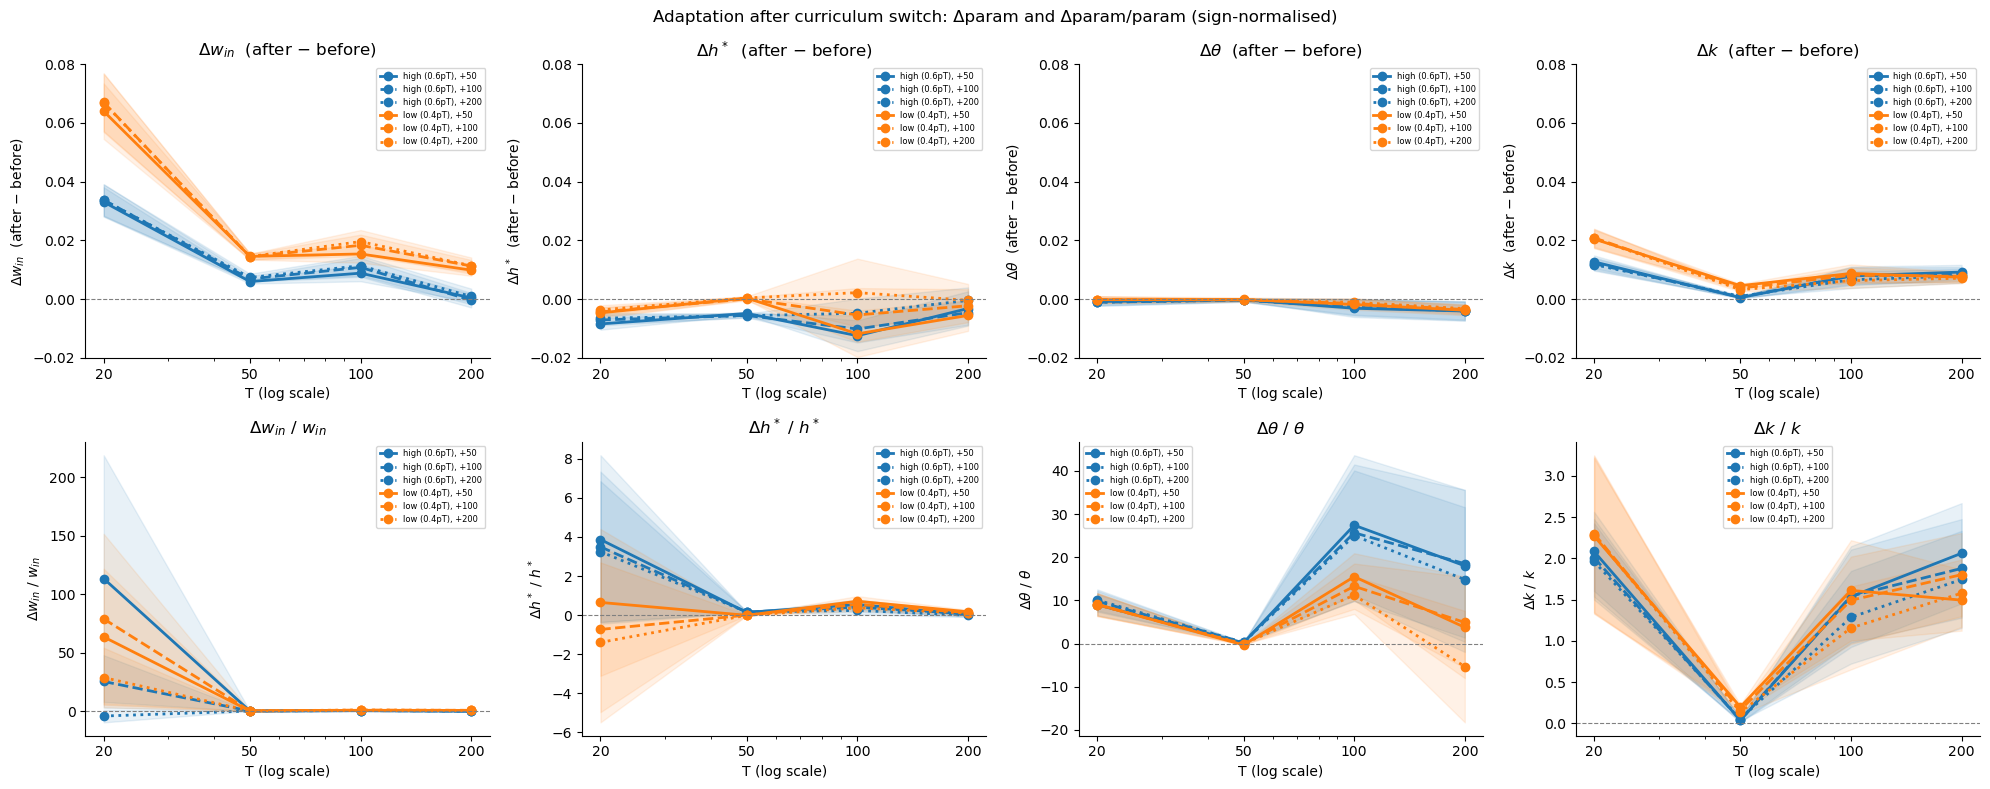

In [288]:
# ── Plot: Δparam and Δparam/param side by side ────────────────────────────────
after_ls = {50: '-', 100: '--', 200: ':'}

VARS_LABELS = [
    ('w_in',      '$w_{in}$'),
    ('h_star',    '$h^*$'),
    ('threshold', '$\\theta$'),
    ('steepness', '$k$'),
]

# Sign-normalise before/after snapshots (flip if final w_in < 0)
SNAP_VARS = ['w_in', 'h_star', 'threshold', 'steepness']
def sign_flip_snaps(r):
    sign = 1 if r['w_in_hist'][-1] >= 0 else -1
    out = dict(r)
    for v in SNAP_VARS:
        out[f'{v}_before'] = sign * r[f'{v}_before']
        for n in [50, 100, 200]:
            key = f'{v}_after_{n}'
            if key in r:
                out[key] = sign * r[key]
    return out

sr_plot = [sign_flip_snaps(r) for r in sweep_results]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, (var, label) in enumerate(VARS_LABELS):
    for row, (use_rel, ylabel) in enumerate([
        (False, f'\u0394{label}  (after \u2212 before)'),
        (True,  f'\u0394{label} / {label}'),
    ]):
        ax = axes[row, col]
        for cond_name, color in zip(cond_names, colors):
            for n_steps, ls in after_ls.items():
                vals, sems = [], []
                for T_val in T_VALUES:
                    rows = [r for r in sr_plot
                            if r['T'] == T_val and r['condition'] == cond_name]
                    if not rows: vals.append(np.nan); sems.append(0); continue
                    after  = np.array([r[f'{var}_after_{n_steps}'] for r in rows])
                    before = np.array([r[f'{var}_before']          for r in rows])
                    d = after - before
                    if use_rel:
                        d = d / (before + 1e-8)
                    vals.append(d.mean())
                    sems.append(d.std() / np.sqrt(len(d)))
                vals, sems = np.array(vals), np.array(sems)
                ax.plot(T_VALUES, vals, marker='o', lw=2,
                        color=color, ls=ls,
                        label=f'{cond_name}, +{n_steps}')
                ax.fill_between(T_VALUES, vals - sems, vals + sems,
                                alpha=0.1, color=color)
        ax.axhline(0, ls='--', c='gray', lw=0.8)
        ax.set_xscale('log')
        ax.set_xlabel('T (log scale)')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.set_xticks(T_VALUES); ax.set_xticklabels(T_VALUES)
        ax.legend(fontsize=6)
        ax.spines[['top', 'right']].set_visible(False)
        if row == 0:
            ax.set_ylim(-0.02, 0.08)

fig.suptitle('Adaptation after curriculum switch: \u0394param and \u0394param/param (sign-normalised)')
fig.tight_layout()
plt.show()


KeyError: 'steepness_after_100'

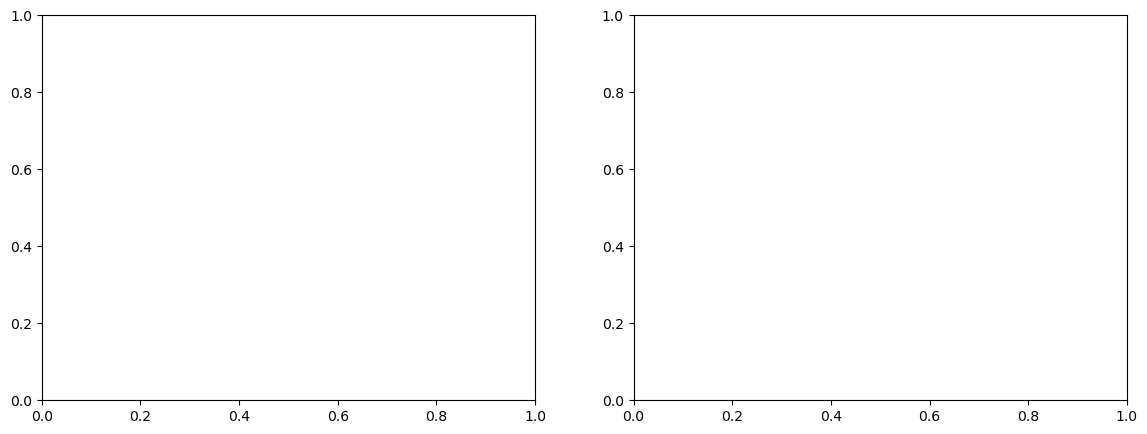

In [278]:
# ── Plot: Δparam contribution to pre-Heaviside readout at n_thresh_2 ──────────
# At threshold crossing: h ≈ h* + w_in * n2  (approx, ignoring W_rec/b)
# Pre-Heaviside value:  f = k * c0 * (h* + w_in * n2) + theta
# For each param p:   Δf_p = f(after) − f(after, but p = p_before)

def f_val(k, h_star, w_in, theta, n2):
    return k * (h_star + w_in * n2) + theta

PARAM_COLORS = {'w_in': 'C0', 'h_star': 'C1', 'threshold': 'C2', 'steepness': 'C3'}
PARAM_LABELS = {'w_in': '$w_{in}$', 'h_star': '$h^*$',
                'threshold': r'$\theta$', 'steepness': '$k$'}
after_ls = {100: '-', 250: '--', 500: ':'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cond_name, factor) in zip(axes, CONDITIONS.items()):
    for param, color in PARAM_COLORS.items():
        for n_steps, ls in after_ls.items():
            means, sems = [], []
            for T_val in T_VALUES:
                n2 = int(round(P * T_val * factor))
                rows = [r for r in sweep_results
                        if r['T'] == T_val and r['condition'] == cond_name]
                if not rows:
                    means.append(np.nan); sems.append(0); continue
                per_seed = []
                for r in rows:
                    k_a  = r[f'steepness_after_{n_steps}']
                    hs_a = r[f'h_star_after_{n_steps}']
                    wi_a = r[f'w_in_after_{n_steps}']
                    th_a = r[f'threshold_after_{n_steps}']
                    k_b  = r['steepness_before']
                    hs_b = r['h_star_before']
                    wi_b = r['w_in_before']
                    th_b = r['threshold_before']
                    f_full = f_val(k_a, hs_a, wi_a, th_a, n2)
                    if param == 'w_in':
                        f_no_p = f_val(k_a, hs_a, wi_b, th_a, n2)
                    elif param == 'h_star':
                        f_no_p = f_val(k_a, hs_b, wi_a, th_a, n2)
                    elif param == 'threshold':
                        f_no_p = f_val(k_a, hs_a, wi_a, th_b, n2)
                    else:  # steepness
                        f_no_p = f_val(k_b, hs_a, wi_a, th_a, n2)
                    per_seed.append(f_full - f_no_p)
                per_seed = np.array(per_seed)
                means.append(per_seed.mean())
                sems.append(per_seed.std() / np.sqrt(len(per_seed)))
            means, sems = np.array(means), np.array(sems)
            label = f'{PARAM_LABELS[param]}, +{n_steps}' if n_steps == 100 else f'+{n_steps}'
            ax.plot(T_VALUES, means, marker='o', lw=2, color=color, ls=ls, label=label)
            ax.fill_between(T_VALUES, means - sems, means + sems, alpha=0.1, color=color)
    ax.axhline(0, ls='--', c='gray', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('T (log scale)')
    ax.set_ylabel('\u0394f  (pre-Heaviside, at $n_2$ crossing)')
    ax.set_title(cond_name)
    ax.set_xticks(T_VALUES); ax.set_xticklabels(T_VALUES)
    ax.legend(fontsize=7, ncol=2)
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


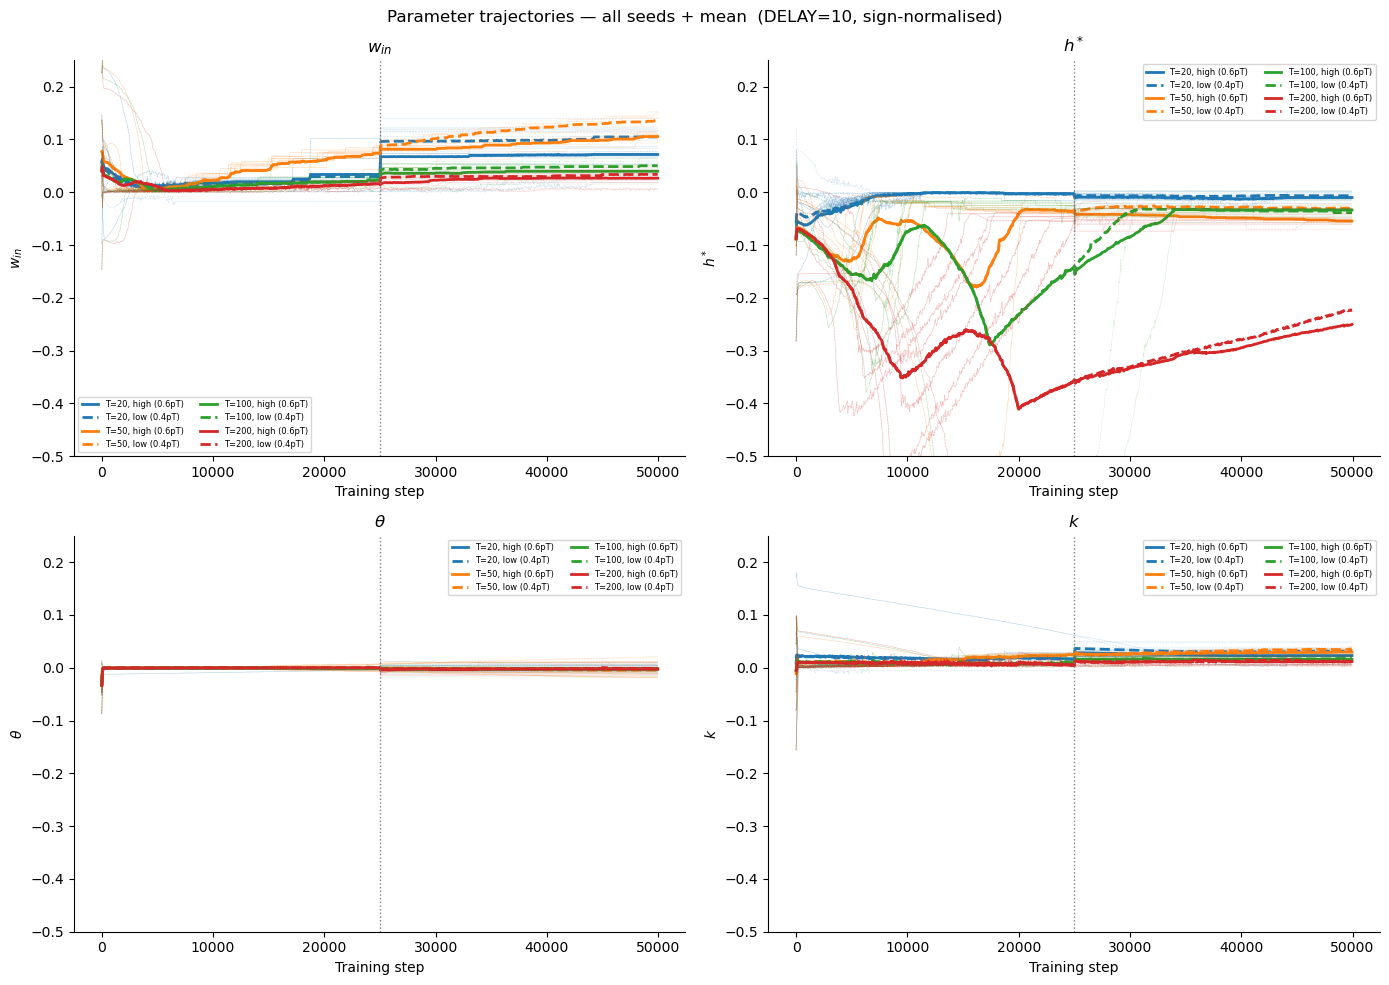

In [283]:
# ── Plot: parameter trajectories ─────────────────────────────────────────────
T_colors = {t: f'C{i}' for i, t in enumerate(T_VALUES)}
cond_ls  = {'high (0.6pT)': '-', 'low (0.4pT)': '--'}
xs = np.array(sweep_steps)

TRAJ_VARS = [('w_in', '$w_{in}$'), ('h_star', '$h^*$'),
             ('threshold', '$\\theta$'), ('steepness', '$k$')]

# Sign-normalise: flip all params for runs where w_in ends negative
FLIP_VARS = ['w_in', 'h_star', 'threshold', 'steepness']
def sign_flip(r):
    sign = 1 if r['w_in_hist'][-1] >= 0 else -1
    out = dict(r)
    for v in FLIP_VARS:
        out[f'{v}_hist'] = [sign * x for x in r[f'{v}_hist']]
    return out

sweep_results_plot = [sign_flip(r) for r in sweep_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flat

for ax, (var, ylabel) in zip(axes_flat, TRAJ_VARS):
    for T_val in T_VALUES:
        for cond_name in CONDITIONS:
            rows  = [r for r in sweep_results_plot
                     if r['T'] == T_val and r['condition'] == cond_name]
            if not rows: continue
            hists = np.array([r[f'{var}_hist'] for r in rows])
            mean  = hists.mean(axis=0)
            color = T_colors[T_val]
            ls    = cond_ls[cond_name]
            for h in hists:
                ax.plot(xs, h, color=color, ls=ls, lw=0.4, alpha=0.2)
            ax.plot(xs, mean, color=color, ls=ls, lw=2.0,
                    label=f'T={T_val}, {cond_name}')
    ax.axvline(switch, c='gray', ls=':', lw=1.0)
    ax.set_xlabel('Training step')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=6, ncol=2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(-0.5, 0.25)

fig.suptitle(f'Parameter trajectories — all seeds + mean  (DELAY={DELAY}, sign-normalised)')
fig.tight_layout()
plt.show()


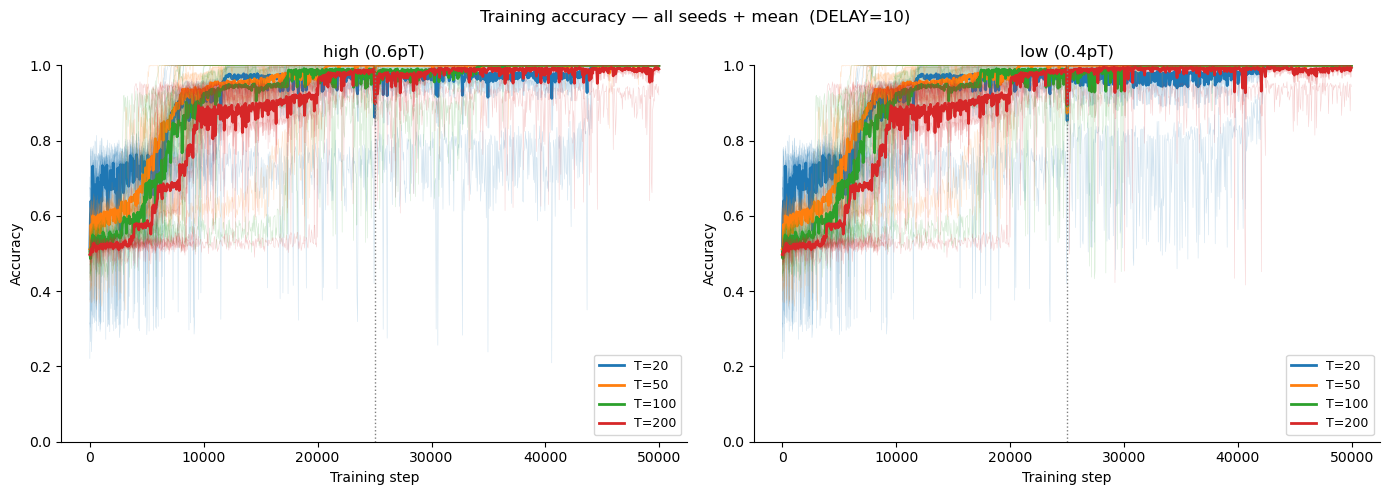

In [280]:
# ── Plot: accuracy trajectories ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cond_name in zip(axes, CONDITIONS):
    for T_val in T_VALUES:
        rows  = [r for r in sweep_results if r['T'] == T_val and r['condition'] == cond_name]
        hists = np.array([r['acc_hist'] for r in rows])
        mean  = hists.mean(axis=0)
        sem   = hists.std(axis=0) / np.sqrt(len(rows))
        color = T_colors[T_val]
        for h in hists:
            ax.plot(xs, h, color=color, lw=0.4, alpha=0.2)
        ax.plot(xs, mean, color=color, lw=2.0, label=f'T={T_val}')
        ax.fill_between(xs, mean - sem, mean + sem, color=color, alpha=0.15)
    ax.axvline(switch, c='gray', ls=':', lw=1.0)
    ax.set_xlabel('Training step')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.set_title(cond_name)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Training accuracy — all seeds + mean  (DELAY={DELAY})')
fig.tight_layout()
plt.show()
